# WS-2 Observation Explorer
**Purpose**: Load the 3D WRF ensemble, compute the ensemble mean in observation space
H(x̄^f), compare with the truth observations yo, and identify three candidate points
for the WS-2 experiment:

| Position | Criterion |
|----------|-----------|
| **A — near mean** | innovation d ≈ 0, ensemble well-covering truth |
| **B — above mean** | large positive d = yo - H(x̄^f), e.g. storm border where ensemble underestimates |
| **C — below mean** | large negative d, e.g. region where ensemble overestimates |

Once you pick the points, paste their coordinates into `configs/ws2.yaml`.


## 0. Configuration

In [1]:
import sys, os
#Set this to your repo root
REPO_ROOT = "/home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation"  # adjust if needed
sys.path.insert(0, REPO_ROOT)
sys.path.insert(0, os.path.join(REPO_ROOT, "src"))
sys.path.insert(0, os.path.join(REPO_ROOT, "src/fortran"))

# Path to your prepared ensemble file 
DATA_FILE = "/home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/3D_subsets/ensemble_3D_sections_2023-12-16_19:00:00.npz"

# Which member to use as truth 
TRUTH_MEMBER = 0   #

#Variable index mapping (must match how the npz was built)
VAR_IDX = {"qg": 0, "qr": 1, "qs": 2, "T": 3, "P": 4, "u": 5, "v": 6, "w": 7}

# Minimum reflectivity threshold to consider a point "precipitating" 
DBZ_MIN = 5.0


## 1. Load ensemble and compute H(x) at every grid point

In [2]:
import numpy as np

data = np.load(DATA_FILE)
# Try both possible array keys
if "state_ensemble" in data:
    ens = data["state_ensemble"]   # (nx, ny, nz, Ne_tot, nvar)
elif "cross_sections" in data:
    ens = data["cross_sections"]
else:
    raise KeyError(f"Expected 'state_ensemble' or 'cross_sections', got: {list(data.keys())}")

print(f"Loaded array shape: {ens.shape}")
print(f"Dimensions: nx={ens.shape[0]}, ny={ens.shape[1]}, nz={ens.shape[2]}, "
      f"Ne_tot={ens.shape[3]}, nvar={ens.shape[4]}")

# Split truth and prior ensemble
mask = np.zeros(ens.shape[3], dtype=bool)
mask[TRUTH_MEMBER] = True
truth = ens[:, :, :, mask,  :][:, :, :, 0, :]   # (nx, ny, nz, nvar)
xf    = ens[:, :, :, ~mask, :]                   # (nx, ny, nz, Ne, nvar)
nx, ny, nz, Ne, nvar = xf.shape
print(f"\nTruth member : {TRUTH_MEMBER}")
print(f"Ensemble size: Ne = {Ne}")
print(f"Domain       : {nx} x {ny} x {nz}")


Loaded array shape: (106, 116, 43, 30, 8)
Dimensions: nx=106, ny=116, nz=43, Ne_tot=30, nvar=8

Truth member : 0
Ensemble size: Ne = 29
Domain       : 106 x 116 x 43


In [3]:
from cletkf_wloc import common_da as cda

def compute_ref_field(state, var_idx):
    """Compute reflectivity at every (x,y,z) for a single member or mean state.
    state: (nx, ny, nz, nvar)
    returns: (nx, ny, nz)
    """
    nx_, ny_, nz_ = state.shape[:3]
    ref = np.full((nx_, ny_, nz_), -20.0, dtype=np.float32)
    for ix in range(nx_):
        for iy in range(ny_):
            for iz in range(nz_):
                ref[ix, iy, iz] = cda.calc_ref(
                    state[ix, iy, iz, var_idx["qr"]],
                    state[ix, iy, iz, var_idx["qs"]],
                    state[ix, iy, iz, var_idx["qg"]],
                    state[ix, iy, iz, var_idx["T"]],
                    state[ix, iy, iz, var_idx["P"]],
                )
    return ref

# Truth reflectivity
print("Computing truth reflectivity...")
yo_field = compute_ref_field(truth, VAR_IDX)          # (nx, ny, nz)

# Ensemble mean reflectivity  (mean of H(x^f), not H(mean(x^f)) — these differ nonlinearly)
print("Computing ensemble reflectivity (this takes a moment)...")
hxf_all = np.stack([compute_ref_field(xf[:,:,:,m,:], VAR_IDX) for m in range(Ne)], axis=-1)
# hxf_all: (nx, ny, nz, Ne)

hxf_mean = hxf_all.mean(axis=-1)    # (nx, ny, nz)  ensemble mean in obs space
hxf_std  = hxf_all.std(axis=-1)     # (nx, ny, nz)  ensemble spread in obs space

# Innovation field
innovation = yo_field - hxf_mean    # d = yo - H(x̄^f)

print(f"\nDone.")
print(f"  yo range      : [{yo_field.min():.1f}, {yo_field.max():.1f}] dBZ")
print(f"  H(x̄^f) range  : [{hxf_mean.min():.1f}, {hxf_mean.max():.1f}] dBZ")
print(f"  innovation     : [{innovation.min():.1f}, {innovation.max():.1f}] dBZ")
print(f"  ensemble spread: [{hxf_std.min():.2f}, {hxf_std.max():.2f}] dBZ")


Computing truth reflectivity...
Computing ensemble reflectivity (this takes a moment)...

Done.
  yo range      : [-20.0, 67.0] dBZ
  H(x̄^f) range  : [-20.0, 51.9] dBZ
  innovation     : [-54.5, 69.7] dBZ
  ensemble spread: [0.00, 35.14] dBZ


## 2. 2D cross-sections to identify candidate points

We show horizontal slices (x–y) at a fixed level z, and vertical slices (x–z) at fixed y.
Adjust `Z_LEVEL` and `Y_SLICE` below to explore the storm.


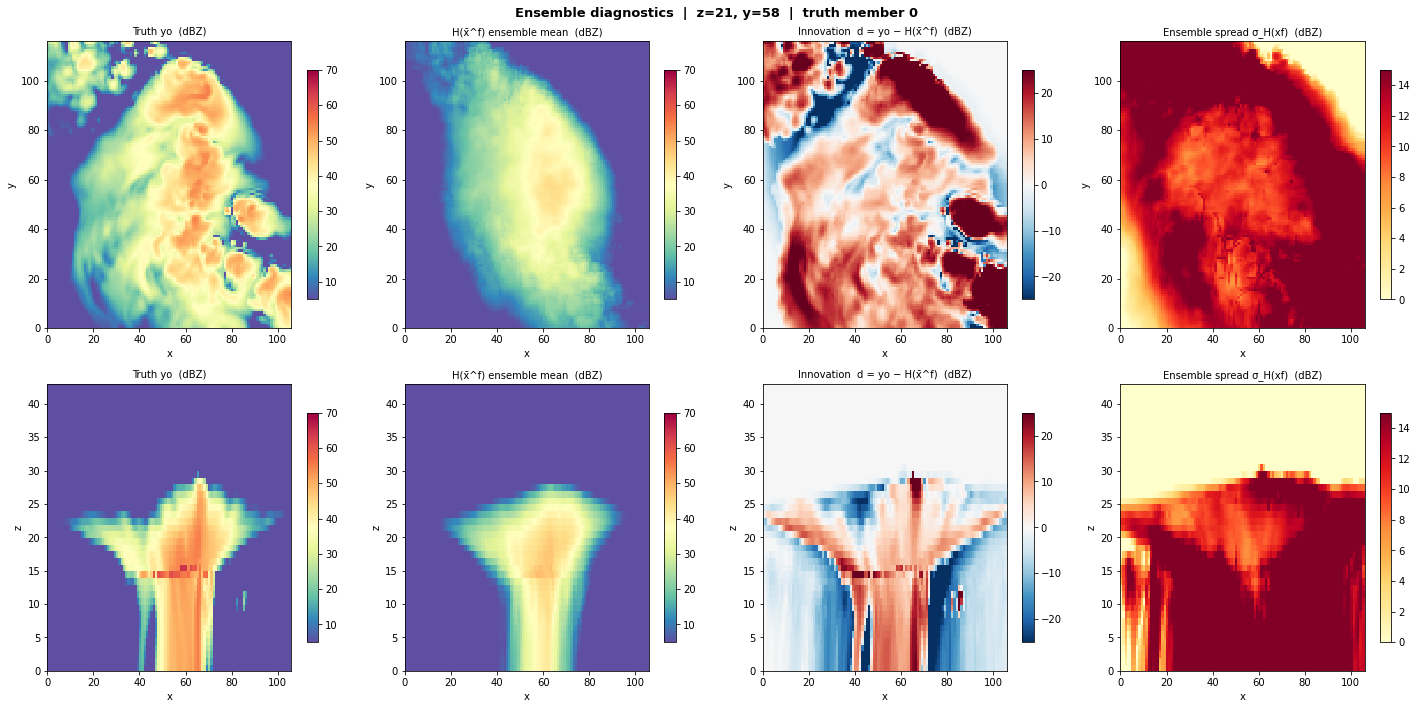

In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

Z_LEVEL = nz // 2    # ← adjust to show interesting level
Y_SLICE = ny // 2    # ← adjust (for 2D data with ny=1, keep as 0)

# Masks: only show precipitating points (yo > DBZ_MIN)
precip_mask_truth = yo_field > DBZ_MIN

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(f"Ensemble diagnostics  |  z={Z_LEVEL}, y={Y_SLICE}  |  truth member {TRUTH_MEMBER}",
             fontsize=13, fontweight='bold')
titles = ["Truth yo  (dBZ)", "H(x̄^f) ensemble mean  (dBZ)", "Innovation  d = yo − H(x̄^f)  (dBZ)", "Ensemble spread σ_H(xf)  (dBZ)"]
# ---- Row 0: horizontal slice at Z_LEVEL ----

data0   = [yo_field[:,:,Z_LEVEL], hxf_mean[:,:,Z_LEVEL], innovation[:,:,Z_LEVEL], hxf_std[:,:,Z_LEVEL]]
cmaps0  = ["Spectral_r", "Spectral_r", "RdBu_r", "YlOrRd"]
vlims0  = [(DBZ_MIN, 70), (DBZ_MIN, 70), (-25, 25), (0, 15)]

for ax, title, dat, cmap, (vmin, vmax) in zip(axes[0], titles, data0, cmaps0, vlims0):
    im = ax.pcolormesh(dat.T, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, shrink=0.8)

# ---- Row 1: vertical cross-section at Y_SLICE ----

data1   = [yo_field[:,Y_SLICE,:], hxf_mean[:,Y_SLICE,:], innovation[:,Y_SLICE,:], hxf_std[:,Y_SLICE,:]]
cmaps1  = ["Spectral_r", "Spectral_r", "RdBu_r", "YlOrRd"]
vlims1  = [(DBZ_MIN, 70), (DBZ_MIN, 70), (-25, 25), (0, 15)]

for ax, title, dat, cmap, (vmin, vmax) in zip(axes[1], titles, data1, cmaps1, vlims1):
    im = ax.pcolormesh(dat.T, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x"); ax.set_ylabel("z")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()


## 3. Innovation distribution (precipitating points only)

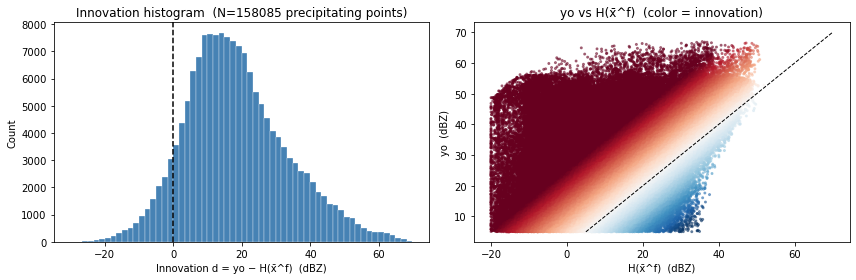

Innovation stats (precipitating points):
  mean  = 18.45 dBZ
  std   = 14.91 dBZ
  min   = -29.83 dBZ
  max   = 69.67 dBZ
  |d|>10: 112907 pts  (71.4%)


In [8]:
precip = yo_field > DBZ_MIN
d_precip = innovation[precip]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(d_precip, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='k', lw=1.5, ls='--')
axes[0].set_xlabel("Innovation d = yo − H(x̄^f)  (dBZ)")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Innovation histogram  (N={precip.sum()} precipitating points)")

axes[1].scatter(hxf_mean[precip], yo_field[precip],
                c=innovation[precip], cmap='RdBu_r', vmin=-25, vmax=25,
                s=4, alpha=0.5)
axes[1].plot([DBZ_MIN, 70], [DBZ_MIN, 70], 'k--', lw=1)
axes[1].set_xlabel("H(x̄^f)  (dBZ)")
axes[1].set_ylabel("yo  (dBZ)")
axes[1].set_title("yo vs H(x̄^f)  (color = innovation)")
plt.tight_layout()
plt.show()

print(f"Innovation stats (precipitating points):")
print(f"  mean  = {d_precip.mean():.2f} dBZ")
print(f"  std   = {d_precip.std():.2f} dBZ")
print(f"  min   = {d_precip.min():.2f} dBZ")
print(f"  max   = {d_precip.max():.2f} dBZ")
print(f"  |d|>10: {(np.abs(d_precip)>10).sum()} pts  ({(np.abs(d_precip)>10).mean()*100:.1f}%)")


## 4. Candidate point finder

This cell automatically finds good candidates for each WS-2 position.
You can also override manually by setting `MANUAL_POINTS` below.


In [9]:
from scipy.ndimage import maximum_filter
import numpy as np

# Only consider precipitating points with some ensemble spread
# (spread > 0 means the point is scientifically interesting)
valid = (yo_field > DBZ_MIN) & (hxf_std > 1.0)

#Position A: near ensemble mean 
# Want: |d| small, yo strong, good spread
score_A = -np.abs(innovation) + (yo_field > 30) * 5
score_A[~valid] = -9999
idx_A = np.unravel_index(score_A.argmax(), score_A.shape)

# Position B: large positive innovation (ensemble underestimates) 
score_B = innovation.copy()
score_B[~valid] = -9999
idx_B = np.unravel_index(score_B.argmax(), score_B.shape)

# Position C: large negative innovation (ensemble overestimates)
score_C = -innovation.copy()
score_C[~valid] = -9999
idx_C = np.unravel_index(score_C.argmax(), score_C.shape)

candidates = {
    "A_near_mean":  idx_A,
    "B_above_mean": idx_B,
    "C_below_mean": idx_C,
}

print("=" * 60)
print("CANDIDATE POINTS FOR WS-2")
print("=" * 60)
for name, (ix, iy, iz) in candidates.items():
    d   = innovation[ix, iy, iz]
    yo_ = yo_field[ix, iy, iz]
    hx_ = hxf_mean[ix, iy, iz]
    sp_ = hxf_std[ix, iy, iz]
    print(f"\n  {name}")
    print(f"    location    : x={ix}, y={iy}, z={iz}")
    print(f"    yo          : {yo_:.2f} dBZ")
    print(f"    H(x̄^f)      : {hx_:.2f} dBZ")
    print(f"    innovation d: {d:+.2f} dBZ")
    print(f"    spread σ_H  : {sp_:.2f} dBZ")
    print(f"    d/σ_H       : {d/max(sp_,0.1):+.2f}")

print("\n" + "=" * 60)
print("Paste the following into configs/ws2.yaml:")
print("=" * 60)
print("obs_positions:")
for name, (ix, iy, iz) in candidates.items():
    print(f"  {name}: {{x: {ix}, y: {iy}, z: {iz}}}")


CANDIDATE POINTS FOR WS-2

  A_near_mean
    location    : x=57, y=74, z=20
    yo          : 39.01 dBZ
    H(x̄^f)      : 39.01 dBZ
    innovation d: -0.00 dBZ
    spread σ_H  : 14.11 dBZ
    d/σ_H       : -0.00

  B_above_mean
    location    : x=66, y=108, z=9
    yo          : 52.57 dBZ
    H(x̄^f)      : -17.10 dBZ
    innovation d: +69.67 dBZ
    spread σ_H  : 10.68 dBZ
    d/σ_H       : +6.52

  C_below_mean
    location    : x=42, y=79, z=14
    yo          : 5.12 dBZ
    H(x̄^f)      : 34.95 dBZ
    innovation d: -29.83 dBZ
    spread σ_H  : 18.22 dBZ
    d/σ_H       : -1.64

Paste the following into configs/ws2.yaml:
obs_positions:
  A_near_mean: {x: 57, y: 74, z: 20}
  B_above_mean: {x: 66, y: 108, z: 9}
  C_below_mean: {x: 42, y: 79, z: 14}


## 5. Vertical profiles at candidate points

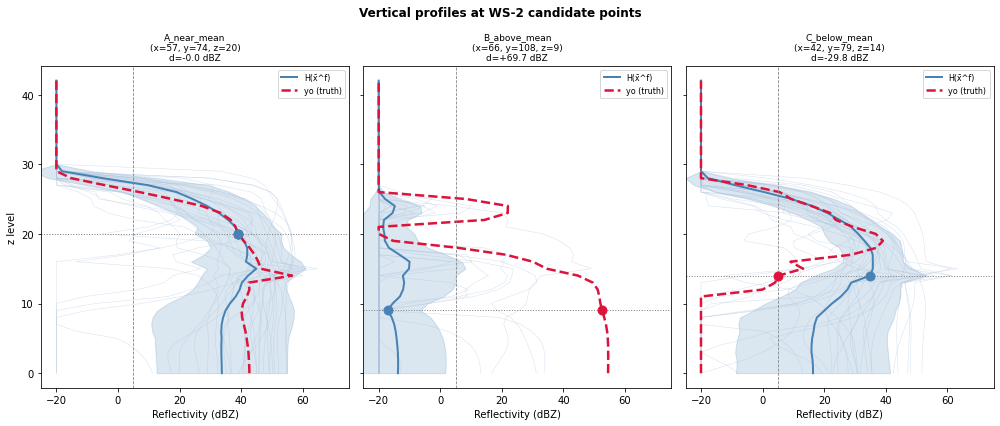

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=True)
fig.suptitle("Vertical profiles at WS-2 candidate points", fontsize=12, fontweight='bold')

colors_members = plt.cm.Blues(np.linspace(0.3, 0.9, Ne))

for ax, (name, (ix, iy, iz)) in zip(axes, candidates.items()):
    zlevs = np.arange(nz)

    # Individual members
    for m in range(Ne):
        ax.plot(hxf_all[ix, iy, :, m], zlevs, color='lightsteelblue', lw=0.5, alpha=0.5)

    # Ensemble mean
    ax.plot(hxf_mean[ix, iy, :], zlevs, color='steelblue', lw=2, label='H(x̄^f)')

    # Ensemble mean ± spread
    ax.fill_betweenx(zlevs,
                     hxf_mean[ix, iy, :] - hxf_std[ix, iy, :],
                     hxf_mean[ix, iy, :] + hxf_std[ix, iy, :],
                     color='steelblue', alpha=0.2)

    # Truth
    ax.plot(yo_field[ix, iy, :], zlevs, color='crimson', lw=2.5, ls='--', label='yo (truth)')

    # Mark chosen level
    ax.axhline(iz, color='gray', lw=1, ls=':')
    ax.scatter([yo_field[ix, iy, iz]], [iz], color='crimson', s=80, zorder=5)
    ax.scatter([hxf_mean[ix, iy, iz]], [iz], color='steelblue', s=80, zorder=5)

    d_ = innovation[ix, iy, iz]
    ax.set_title(f"{name}\n(x={ix}, y={iy}, z={iz})\nd={d_:+.1f} dBZ", fontsize=9)
    ax.set_xlabel("Reflectivity (dBZ)")
    ax.axvline(DBZ_MIN, color='gray', lw=0.8, ls='--')
    if ax == axes[0]:
        ax.set_ylabel("z level")
    ax.legend(fontsize=8)
    ax.set_xlim(-25, 75)

plt.tight_layout()
plt.show()


## 6. Manual point selection (optional)

If you want to override the automatic suggestions, set coordinates here and re-run the diagnostics.


In [ ]:
# ── MANUAL OVERRIDE ── set to None to use automatic candidates above ─────
MANUAL_A = None   # e.g. (30, 0, 18)
MANUAL_B = None   # e.g. (45, 0, 22)
MANUAL_C = None   # e.g. (20, 0, 14)

if MANUAL_A: candidates["A_near_mean"]  = MANUAL_A
if MANUAL_B: candidates["B_above_mean"] = MANUAL_B
if MANUAL_C: candidates["C_below_mean"] = MANUAL_C

# Print final summary and config snippet
print("FINAL WS-2 OBSERVATION POINTS")
print("=" * 50)
for name, (ix, iy, iz) in candidates.items():
    d   = innovation[ix, iy, iz]
    yo_ = yo_field[ix, iy, iz]
    hx_ = hxf_mean[ix, iy, iz]
    sp_ = hxf_std[ix, iy, iz]
    print(f"  {name:20s}  x={ix:3d} y={iy:2d} z={iz:2d}  "
          f"yo={yo_:5.1f}  H(x̄)={hx_:5.1f}  d={d:+5.1f}  σ_H={sp_:.1f}")

print("\n--- configs/ws2.yaml snippet ---")
print(f"state:")
print(f"  truth_member: {TRUTH_MEMBER}")
print(f"  var_idx: {{qg: 0, qr: 1, qs: 2, T: 3, P: 4, u: 5, v: 6, w: 7}}")
print(f"obs_positions:")
for name, (ix, iy, iz) in candidates.items():
    print(f"  {name}: {{x: {ix}, y: {iy}, z: {iz}}}")
print(f"obs:")
print(f"  sigma_dbz: 5.0")


## 7. Innovation map with selected points

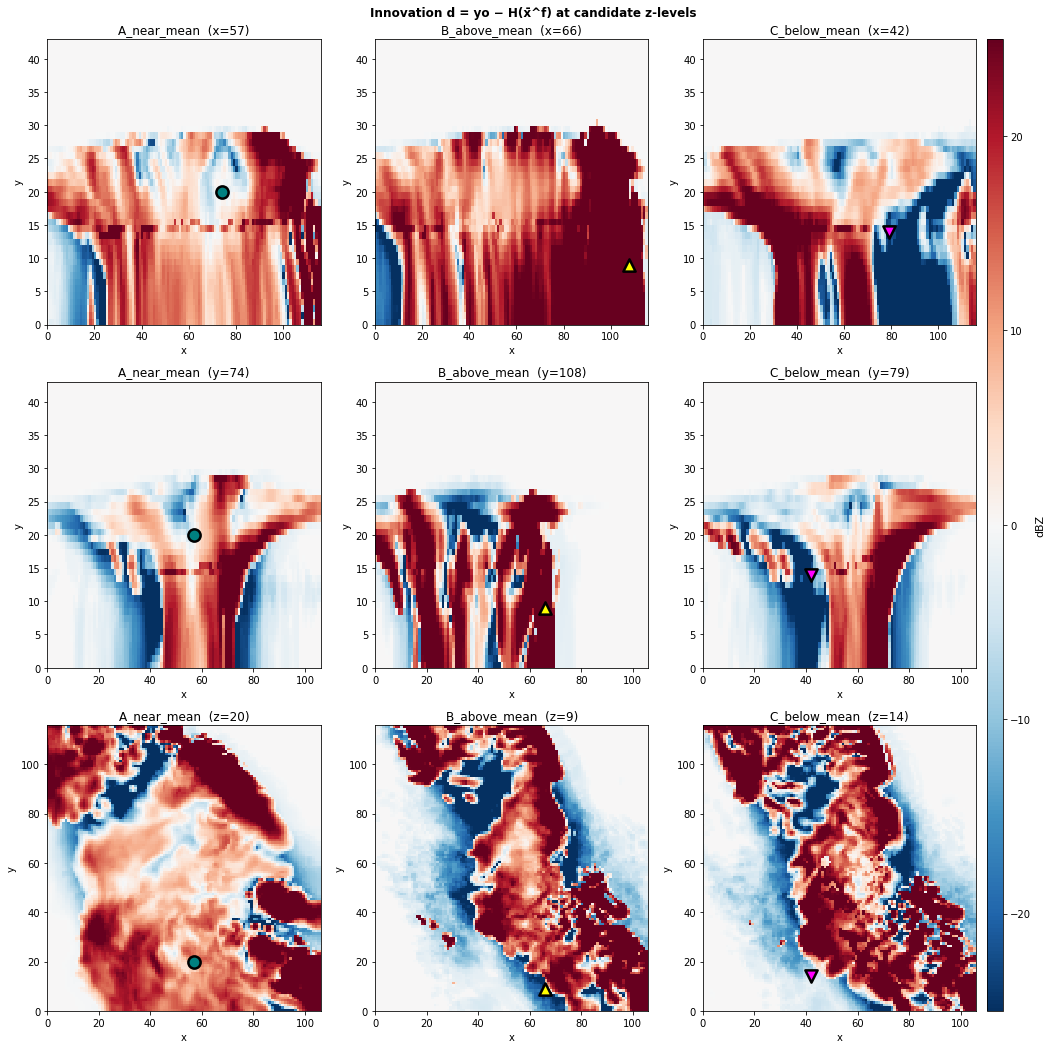

In [ ]:
# Show the innovation at the z-level of each candidate, with the point marked
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle("Innovation d = yo − H(x̄^f) at candidate z-levels", fontsize=12, fontweight='bold')

marker_styles = {'A_near_mean': ('o', 'teal'), 'B_above_mean': ('^', 'teal'), 'C_below_mean': ('v', 'teal')}
for axis in range(3):
    for ax, (name, (ix, iy, iz)) in zip(axes[axis], candidates.items()):
        if axis == 0:
            d_slice = innovation[ix, :, :] if ny > 1 else innovation[:, 0, :]   # x-z if ny=1
            ix_plot, iy_plot = iy, iz
            xlabel, ylabel = "y", "z"
            title_suffix = f"(x={ix})"
        elif axis == 1:
            d_slice = innovation[:, iy, :] if ny > 1 else innovation[:, 0, :]   # x-z if ny=1
            ix_plot, iy_plot = ix, iz
            xlabel, ylabel = "x", "z"
            title_suffix = f"(y={iy})"
        else:
            d_slice = innovation[:, :, iz] if ny > 1 else innovation[:, 0, :]   # x-z if ny=1
            ix_plot, iy_plot = ix, iz
            xlabel, ylabel = "x", "z"
            title_suffix = f"(z={iz})"

        if ny > 1:
            im = ax.pcolormesh(d_slice.T, cmap='RdBu_r', vmin=-25, vmax=25)
            ax.scatter([ix_plot], [iy_plot], marker=marker_styles[name][0],
                    c=marker_styles[name][1], s=150, zorder=5, edgecolors='k', lw=2.5)
            ax.set_xlabel("x"); ax.set_ylabel("y")
            ax.set_title(f"{name}  {title_suffix}")
        else:
            # ny=1: show x-z cross-section
            d_slice = innovation[:, 0, :]
            im = ax.pcolormesh(d_slice.T, cmap='RdBu_r', vmin=-25, vmax=25)
            ax.scatter([ix_plot], [iy_plot], marker=marker_styles[name][0],
                    c=marker_styles[name][1], s=120, zorder=5, edgecolors='k', lw=1.5)
            ax.set_xlabel("x"); ax.set_ylabel("z")
            ax.set_title(f"{name}  {title_suffix}")

#plt.colorbar(im, ax=ax, shrink=0.8, label="dBZ")
cbar_ax = fig.add_axes([0.92, 0.05, 0.015, 0.9])
fig.colorbar(im, cax=cbar_ax).set_label("dBZ", fontsize=11)
plt.subplots_adjust(right=0.91, left=0.05, top=0.95, bottom=0.05)
#plt.tight_layout()
plt.show()
